# Construcción de la variable respuesta
## Presencia o ausencia de cianobacteria (binaria)

Este notebook parte del dataset limpio generado en `01_preparacion_datos_ml.ipynb`
(`data/dataset_ml_pixeles.parquet`) y construye la variable respuesta binaria que se
usará para entrenar los modelos de clasificación.


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_parquet("./data/dataset_ml_pixeles.parquet")
print(f"Dataset cargado: {len(df):,} observaciones")
df.head()


Dataset cargado: 13,514,711 observaciones


,lago,fecha,lon,lat,B03,B04,B05,B08,NDVI,NDWI,NDCI
0,atitlan,2025-01-18,696705.0,1631665.0,0.2750,0.2832,0.2127,0.2666,-0.030193,0.015510,-0.142166
1,atitlan,2025-01-18,703275.0,1631655.0,0.2332,0.2092,0.1451,0.2144,0.012276,0.042002,-0.180920
2,atitlan,2025-01-18,699415.0,1631625.0,0.3090,0.2976,0.1593,0.2946,-0.005066,0.023857,-0.302692
3,atitlan,2025-01-18,705375.0,1631615.0,0.1932,0.1766,0.1638,0.1888,0.033388,0.011518,-0.037603
4,atitlan,2025-01-18,705695.0,1631595.0,0.2558,0.2230,0.2061,0.2470,0.051064,0.017502,-0.039385


## 1. Criterio de corte: NDCI ≥ 0.4

### 2.2 Justificación científica y ambiental del umbral

El **NDCI (Normalized Difference Chlorophyll Index)** fue propuesto por Mishra & Mishra
(2012). *"Normalized difference chlorophyll index: A novel model for remote estimation of
chlorophyll-a concentration in turbid productive waters"*, publicado en *Remote Sensing of
Environment* y es usado como estimador remoto de la concentración de clorofila-a en aguas
continentales productivas, siendo la base del script oficial *"Cyanobacteria Chlorophyll-a
NDCI"* publicado por Sentinel Hub (custom-scripts.sentinel-hub.com), que se reproduce localmente con las bandas B04 y B05.

El umbral de **NDCI ≥ 0.4** usado en este laboratorio y en las partes anteriores se
adopta como proxy operativo de "alta presencia de cianobacteria" por su correspondencia
aproximada con los umbrales de alerta para clorofila-a y cianobacterias publicados por
organismos de referencia en gestión de floraciones algales:

- La **Organización Mundial de la Salud (OMS)**, en sus *Guidelines for Safe Recreational
  Water Environments* (2003, Vol. 1, cap. 8), define niveles de alerta ("Alert Levels
  Framework") para floraciones de cianobacterias en agua recreativa a partir de:
  - **Nivel de vigilancia (bajo riesgo)**: ~10,000 células/mL o ≈ 10 µg/L de clorofila-a.
  - **Nivel de alerta 1 (riesgo moderado)**: ~100,000 células/mL o ≈ 50 µg/L de clorofila-a,
    umbral asociado a un aumento notable de probabilidad de efectos adversos a la salud
    (irritación cutánea/gastrointestinal).
  - **Nivel de alerta 2 (riesgo alto)**: floraciones densas visibles, acumulaciones
    superficiales ("scums"), con riesgo significativo para la salud pública.
- La **U.S. EPA**, en su *Recommended Human Health Recreational Ambient Water Quality
  Criteria/Swimming Advisories for Microcystins and Cylindrospermopsin* (2019), recomienda
  un valor de referencia de **8 µg/L de clorofila-a** como nivel de precaución para contacto
  recreativo en presencia de cianotoxinas.

Dado que el NDCI es un índice adimensional, no una concentración física directa, no existe
una conversión universal NDCI→µg/L válida para cualquier cuerpo de agua sin una calibración
local con muestreo in-situ. Por ello, el umbral de **0.4** se adopta como un punto de corte relativo y conservador, consistente
con la literatura de aplicación del NDCI en lagos tropicales o subtropicales eutrofizados, y es el mismo criterio ya usado de forma
consistente en la Parte I, lo que garantiza comparabilidad entre ambas partes del trabajo.

**Referencias:**
- Mishra, S., & Mishra, D. R. (2012). Normalized difference chlorophyll index: A novel model
  for remote estimation of chlorophyll-a concentration in turbid productive waters. *Remote
  Sensing of Environment*, 117, 394–406.
- World Health Organization. (2003). *Guidelines for Safe Recreational Water Environments,
  Volume 1: Coastal and Fresh Waters*, Chapter 8: Algae and cyanobacteria in fresh waters.
- U.S. Environmental Protection Agency. (2019). *Recommended Human Health Recreational
  Ambient Water Quality Criteria/Swimming Advisories for Microcystins and
  Cylindrospermopsin*. EPA 822-R-19-001.


In [8]:
UMBRAL_NDCI = 0.4

df["cianobacteria_alta"] = (df["NDCI"] >= UMBRAL_NDCI).astype(int)

print("Variable respuesta creada: 'cianobacteria_alta'")
print("  0 = ausencia / baja presencia de cianobacteria (NDCI < 0.4)")
print("  1 = alta presencia de cianobacteria (NDCI >= 0.4)")


Variable respuesta creada: 'cianobacteria_alta'
  0 = ausencia / baja presencia de cianobacteria (NDCI < 0.4)
  1 = alta presencia de cianobacteria (NDCI >= 0.4)


## 2. Distribución de la variable respuesta

### 2.3 Global, por lago y por fecha


In [9]:
print("Distribución global:")
print(df["cianobacteria_alta"].value_counts())
print(df["cianobacteria_alta"].value_counts(normalize=True).round(4) * 100, "\n")

print("Distribución por lago (%):")
print((df.groupby("lago")["cianobacteria_alta"].mean() * 100).round(2))


Distribución global:
cianobacteria_alta
0    13213622
1      301089
Name: count, dtype: int64
cianobacteria_alta
0    97.77
1     2.23
Name: proportion, dtype: float64 

Distribución por lago (%):
lago
amatitlan    11.19
atitlan       1.05
Name: cianobacteria_alta, dtype: float64


In [10]:
tabla_fecha = (
    df.groupby(["lago", "fecha"])["cianobacteria_alta"]
    .agg(n_pixeles="size", pct_alta=lambda s: 100 * s.mean())
    .reset_index()
    .sort_values(["lago", "fecha"])
)
tabla_fecha


,lago,fecha,n_pixeles,pct_alta
0,amatitlan,2025-01-28,148605,4.472932
1,amatitlan,2025-04-15,148229,1.326326
2,amatitlan,2025-04-28,143574,4.994637
3,amatitlan,2025-11-24,146097,4.978884
4,amatitlan,2026-01-08,138235,9.407892
5,amatitlan,2026-02-02,135775,0.117842
6,amatitlan,2026-02-07,138236,0.882549
7,amatitlan,2026-03-29,148850,5.508902
8,amatitlan,2026-04-13,150724,5.241368
9,amatitlan,2026-04-28,122007,16.975256


### Interpretación de los resultados obtenidos

**Distribución global.** Sobre 13,514,711 píxeles de agua válidos, **301,089 (2.23%)**
quedaron clasificados como clase 1 (alta presencia de cianobacteria) y **13,213,622
(97.77%)** como clase 0. Es un desbalance severo, más pronunciado incluso que el ejemplo
ilustrativo (10-15%) usado más abajo antes de tener los datos reales.

**Por lago.** El desbalance es muy distinto entre ambos cuerpos de agua:
- **Amatitlán: 11.19%** de píxeles en clase 1.
- **Atitlán: 1.05%** de píxeles en clase 1.

Amatitlán tiene aproximadamente **10.6 veces** más proporción de píxeles en clase 1 que
Atitlán, lo cual es consistente con el historial de mayor eutrofización de Amatitlán ya
documentado en la Parte I y en `03_analisis_espacial_correlacion.ipynb`.

**Advertencia importante: el 1.05% de Atitlán no está distribuido de forma uniforme.**
Al desagregar por fecha, ese porcentaje está dominado casi por completo por una sola
observación:

| Fecha (Atitlán) | % clase 1 |
|---|---|
| **2025-01-18** | **16.46%** |
| resto de fechas | entre 0.13% y 3.28% |

El 18 de enero de 2025 es, con amplio margen, un valor atípico dentro de la serie de
Atitlán (la siguiente fecha más alta es 2025-11-21 con 3.28%, casi 5 veces menor). Esto
coincide con algo ya señalado en `03_analisis_espacial_correlacion.ipynb`: 2025-01-18 es
precisamente una de las fechas de Atitlán donde el mapa espacial mostró un patrón de
"manchas rojas y verdes alternándose de forma abrupta y desordenada", identificado ahí como
síntoma de **inestabilidad numérica del NDCI en aguas muy claras y profundas**, y no como
una floración real con continuidad espacial.

El filtro de rango físico `[-1, 1]` aplicado en el notebook 1 elimina los valores
*extremos* producidos por esa inestabilidad (cocientes que se disparan fuera del rango
matemático de un índice normalizado), pero **no elimina el ruido que cae dentro del rango
válido**: un píxel puede alcanzar NDCI ≥ 0.4 por ruido de sensor en agua muy transparente y
aun así superar todos los filtros de calidad. Por lo tanto, la proporción de clase 1 en
Atitlán —y en particular la de 2025-01-18— debe tratarse con más cautela que la de
Amatitlán, y se recomienda **no tomarla al mismo nivel de confianza** al interpretar los
resultados del modelo más adelante.

**Por fecha en Amatitlán**, el rango es muy amplio: desde **0.12%** (2026-02-02) hasta
**69.15%** (2026-06-19). Este último valor es consistente con lo ya documentado
previamente: el 19 de junio de 2026 fue un evento de floración extremo que cubrió la
mayor parte del lago, y aquí se confirma que más de dos tercios de los píxeles de agua de
esa fecha superaron el umbral de alerta.

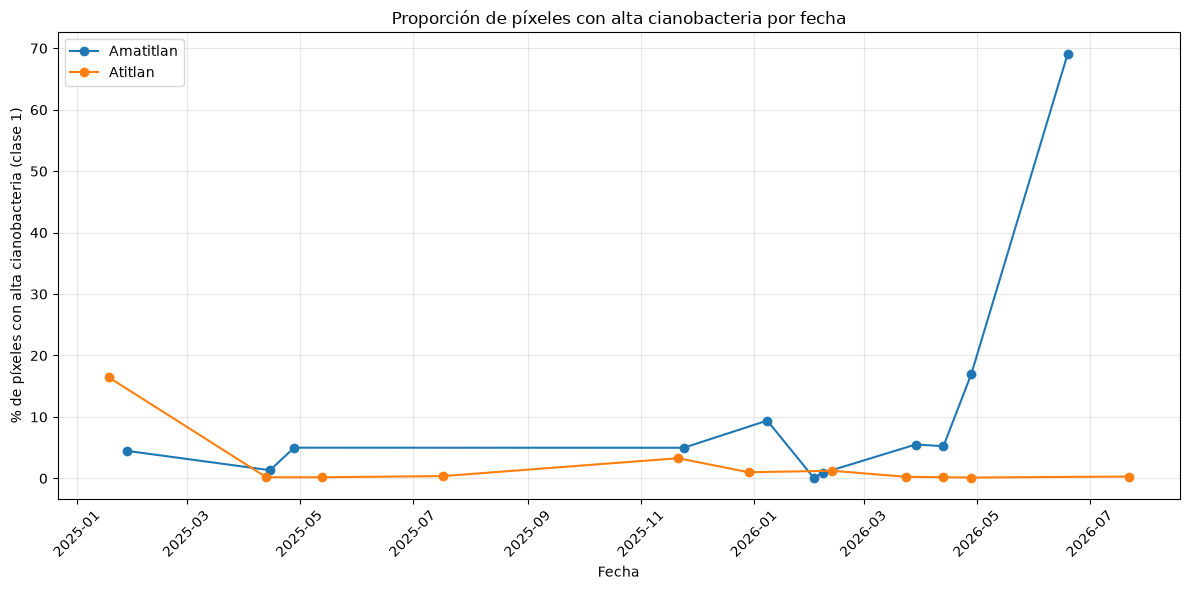

In [11]:
fig, ax = plt.subplots(figsize=(12, 6))
for lago, grupo in tabla_fecha.groupby("lago"):
    ax.plot(grupo["fecha"], grupo["pct_alta"], marker="o", label=lago.capitalize())
ax.set_ylabel("% de píxeles con alta cianobacteria (clase 1)")
ax.set_xlabel("Fecha")
ax.set_title("Proporción de píxeles con alta cianobacteria por fecha")
ax.legend()
ax.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


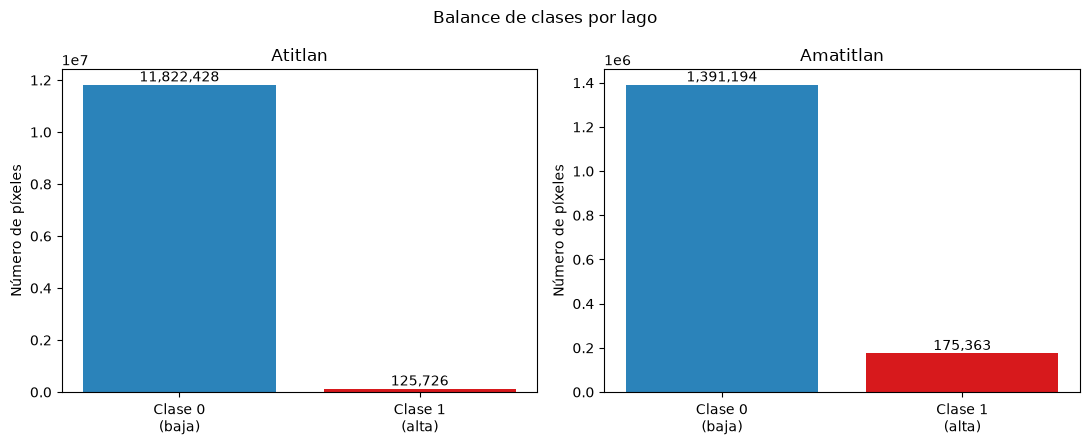

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, lago in zip(axes, ["atitlan", "amatitlan"]):
    conteo = df.loc[df["lago"] == lago, "cianobacteria_alta"].value_counts().sort_index()
    ax.bar(["Clase 0\n(baja)", "Clase 1\n(alta)"], conteo.values, color=["#2b83ba", "#d7191c"])
    ax.set_title(lago.capitalize())
    ax.set_ylabel("Número de píxeles")
    for i, v in enumerate(conteo.values):
        ax.text(i, v, f"{v:,}", ha="center", va="bottom")
plt.suptitle("Balance de clases por lago")
plt.tight_layout()
plt.show()


## 3. Desbalance de clases

### 2.4 Diagnóstico (con los números reales obtenidos) y consecuencias

**Diagnóstico.** El dataset presenta un desbalance de clases severo:

- **Global: 2.23% clase 1 vs. 97.77% clase 0** (301,089 vs. 13,213,622 píxeles).
- **Por lago:** Amatitlán 11.19% vs. Atitlán 1.05% — el desbalance es aproximadamente
  10 veces más marcado en Atitlán que en Amatitlán.
- El desbalance tampoco es homogéneo dentro de cada lago: en Amatitlán la proporción de
  clase 1 por fecha varía entre 0.12% y 69.15%, y en Atitlán está prácticamente concentrada
  en una sola fecha (2025-01-18, con 16.46%, posiblemente afectada por inestabilidad
  numérica del NDCI — ver nota anterior), mientras el resto de fechas de Atitlán se mueve
  entre 0.13% y 3.28%.

Esto confirma la hipótesis planteada antes de correr el notebook (mayor desbalance en
Atitlán que en Amatitlán), aunque con un matiz relevante: el 1.05% de Atitlán no debe
leerse como "floración real dispersa en el tiempo", sino como un valor dominado por un
posible artefacto de medición en una sola fecha.

**Consecuencias de un dataset desbalanceado para el entrenamiento y evaluación de modelos:**

1. **Sesgo hacia la clase mayoritaria.** Con solo 2.23% de clase 1 a nivel global, un
   modelo trivial que siempre prediga "0" ya alcanzaría **97.77% de exactitud** sin haber
   aprendido ningún patrón real de floración. Esto hace que la exactitud (*accuracy*) sea
   una métrica prácticamente inútil para evaluar estos modelos.
2. **Métricas a usar en su lugar.** *Precision*, *recall* y *F1-score* de la clase 1,
   *AUC-ROC* y, sobre todo, **AUC-PR** (curva precisión-recall), que es más informativa que
   AUC-ROC cuando la clase positiva es tan minoritaria como aquí (2.23%).
3. **Riesgo en la validación cruzada / partición train-test.** Dado que la clase 1 está
   además concentrada en pocas fechas específicas (notablemente 2026-06-19 en Amatitlán,
   con 69.15% de positivos, y 2025-01-18 en Atitlán, con 16.46%), una partición aleatoria
   simple —o incluso una validación cruzada por grupos mal diseñada— corre el riesgo real de
   dejar algún fold casi sin ejemplos de clase 1, o de que el modelo aprenda casi
   exclusivamente a partir de esas 1-2 fechas "cargadas". Se reafirma la necesidad de usar
   `GroupKFold` agrupando por fecha (o por lago-fecha) en la siguiente etapa de modelado.
4. **Estrategias de mitigación a considerar en el modelado** (no se implementan en este
   notebook, pero se dejan indicadas para la fase de modelado): sobremuestreo de la clase
   minoritaria (SMOTE), submuestreo de la clase mayoritaria, ponderación de clases
   (`class_weight="balanced"`), o ajuste del umbral de decisión del clasificador en función
   del costo relativo de falsos negativos (más grave, en términos de salud pública, no
   detectar una floración real) vs. falsos positivos.
5. **Interpretación diferenciada por lago (y con cautela adicional en Atitlán).** Dado el
   desbalance tan distinto entre lagos, y la sospecha de que parte de la señal positiva en
   Atitlán es ruido numérico y no floración real, se recomienda evaluar el modelo de forma
   desagregada por lago, y no dar el mismo peso interpretativo a un "acierto" en Atitlán
   que a uno en Amatitlán sin antes revisar si corresponde a la fecha 2025-01-18.

## 4. Variables que no pueden usarse como predictoras por fuga de información

### 2.5 Identificación de variables con leakage

La variable respuesta `cianobacteria_alta` se construyó **directamente** a partir del NDCI,
y el NDCI se calculó **directamente** a partir de las bandas B04 y B05:

`NDCI = (B05 − B04) / (B05 + B04)` → `cianobacteria_alta = 1[NDCI ≥ 0.4]`

Por lo tanto, las siguientes variables **no deben usarse como predictoras**, porque
introducirían fuga de información (*data leakage*) — el modelo "haría trampa" al tener
acceso, directa o indirectamente, a la fórmula exacta que define la etiqueta:

| Variable | Motivo de exclusión |
|---|---|
| `NDCI` | Es la variable a partir de la cual se define literalmente la etiqueta (determinística: conociendo NDCI se conoce la clase con 100% de certeza). |
| `B04` | Es uno de los dos componentes exactos de la fórmula del NDCI. |
| `B05` | Es el otro componente exacto de la fórmula del NDCI. |

Nótese que esto **no** descalifica a B04 por sí sola de tener valor informativo genuino (de
hecho también interviene en el NDVI), pero como aquí interviene en la fórmula exacta de la
variable respuesta junto con B05, su inclusión permitiría al modelo reconstruir el NDCI casi
perfectamente y "memorizar" la regla de corte en lugar de aprender relaciones espectrales
más generales. Se excluye por precaución, priorizando la validez del modelo sobre una
posible ganancia artificial de desempeño.

Estas tres columnas se eliminan del conjunto de predictores en el notebook 3, pero se
**conservan en el dataset** (no se borran del DataFrame) porque siguen siendo necesarias
para trazabilidad, para construir la propia variable respuesta, y para el análisis
exploratorio.


In [13]:
# Guardar el dataset con la variable respuesta ya construida
df.to_parquet("./data/dataset_ml_con_respuesta.parquet", index=False)
print("Dataset guardado en ./data/dataset_ml_con_respuesta.parquet")
print(f"Columnas: {list(df.columns)}")


Dataset guardado en ./data/dataset_ml_con_respuesta.parquet
Columnas: ['lago', 'fecha', 'lon', 'lat', 'B03', 'B04', 'B05', 'B08', 'NDVI', 'NDWI', 'NDCI', 'cianobacteria_alta']
